In [16]:
import os
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
from scipy.ndimage import grey_opening, grey_closing

In [17]:
data_dir = 'data'

In [18]:
df_usd_to_inr = pd.read_csv(os.path.join(data_dir, 'usd_to_inr.csv'))
df_price = pd.read_csv(os.path.join(data_dir, 'rallis_inr.csv'))
df_price = df_price[['date', 'avg']].rename(columns={'avg': 'price_inr'})

In [19]:
df_inr = df_price.merge(df_usd_to_inr, on='date', how='inner')

In [20]:
# check for missing dates
date_range = pd.date_range(start=df_inr['date'].min(), end=df_inr['date'].max())
date_available = pd.to_datetime(df_inr['date'])
missing_dates = date_range.difference(date_available)
print(f'Missing dates: {missing_dates}')

Missing dates: DatetimeIndex(['2008-01-05', '2008-01-06', '2008-01-12', '2008-01-13',
               '2008-01-19', '2008-01-20', '2008-01-26', '2008-01-27',
               '2008-02-02', '2008-02-03',
               ...
               '2026-04-19', '2026-04-25', '2026-04-26', '2026-05-01',
               '2026-05-02', '2026-05-03', '2026-05-09', '2026-05-10',
               '2026-05-16', '2026-05-17'],
              dtype='datetime64[us]', length=2184, freq=None)


In [21]:
# expand df to have all dates, and fill missing price with previous available price
df_inr['date'] = pd.to_datetime(df_inr['date'])
df_inr = df_inr.set_index('date').reindex(date_range).reset_index().rename(columns={'index': 'date'})
df_inr = df_inr.ffill()

In [22]:
df_usd = df_inr.copy()
df_usd['price_usd'] = df_inr['price_inr'] / df_inr['usd_to_inr']
df_usd.to_csv(os.path.join(data_dir, 'rallis_usd.csv'), index=False)

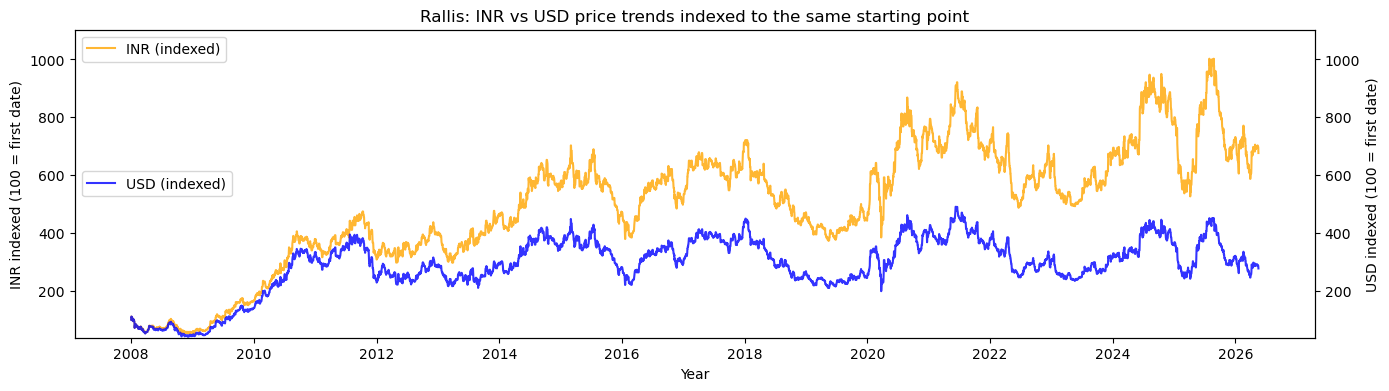

In [23]:
# compare INR and USD trends using a common start baseline
# normalize both series to 100 at the first available date so trends can be compared directly
plot_df = df_inr[['date', 'price_inr']].copy()
plot_df['price_usd'] = df_usd['price_usd'].values
plot_df = plot_df.sort_values('date').reset_index(drop=True)
plot_df['price_inr_indexed'] = plot_df['price_inr'] / plot_df['price_inr'].iloc[0] * 100
plot_df['price_usd_indexed'] = plot_df['price_usd'] / plot_df['price_usd'].iloc[0] * 100

plt.figure(figsize=(16, 4))
ax1 = plt.gca()
ax2 = ax1.twinx()
ax1.set_ylabel('INR indexed (100 = first date)')
ax2.set_ylabel('USD indexed (100 = first date)')
ax1.plot(plot_df['date'], plot_df['price_inr_indexed'], label='INR (indexed)', color='orange', alpha=0.8)
ax2.plot(plot_df['date'], plot_df['price_usd_indexed'], label='USD (indexed)', color='blue', alpha=0.8)

# use the same y-axis limits on both axes so the indexed trends start at the same baseline
ymin = min(plot_df['price_inr_indexed'].min(), plot_df['price_usd_indexed'].min()) * 0.9
ymax = max(plot_df['price_inr_indexed'].max(), plot_df['price_usd_indexed'].max()) * 1.1
ax1.set_ylim(ymin, ymax)
ax2.set_ylim(ymin, ymax)

ax1.set_xlabel('Year')
ax1.legend(loc='upper left')
ax2.legend(loc='center left')
plt.title('Rallis: INR vs USD price trends indexed to the same starting point')
plt.show()